Python Set Up

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Find the directory where notebook is currently saved
notebook_dir = os.getcwd()

# Find the "Parent" directory (the main project folder)
project_root = os.path.dirname(notebook_dir)

# Join them perfectly
order_file_path = os.path.join(project_root, 'Data', 'raw', 'Olist_ecom_data', 'olist_orders_dataset.csv')

# Load the datasets for RFM analysis
order = pd.read_csv(order_file_path)

Exploratory Data Analysis ( EDA ) on orders_dataset.csv

Necessary set up for orders_dataset.csv

In [2]:
# To Explore the data, we need to convert the date columns to datetime format

order['order_purchase_timestamp'] = pd.to_datetime(order['order_purchase_timestamp'])
order['order_delivered_carrier_date'] = pd.to_datetime(order['order_delivered_carrier_date'])
order['order_delivered_customer_date'] = pd.to_datetime(order['order_delivered_customer_date'])
order['order_estimated_delivery_date'] = pd.to_datetime(order['order_estimated_delivery_date'])
order['order_approved_at'] = pd.to_datetime(order['order_approved_at'])

# Order the days correctly
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

In [4]:
order.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


Checking deliverd but missing values

In [15]:
# Check missing values for delivered orders across all date columns
delivered_missing = order[order['order_status'] == 'delivered'][
    ['order_approved_at', 
     'order_delivered_carrier_date', 
     'order_delivered_customer_date', 
     'order_estimated_delivery_date']
].isnull().sum()

print(delivered_missing)

order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64


In [16]:
# Drop only the problematic rows (delivered but no date)
order = order[~(
    (order['order_status'] == 'delivered') & 
    (
        order['order_delivered_customer_date'].isnull() | 
        order['order_delivered_carrier_date'].isnull() |
        order['order_approved_at'].isnull()
    )
)]



Delivery Performance / change dtype of date columns

0


(0.0, 30.0)

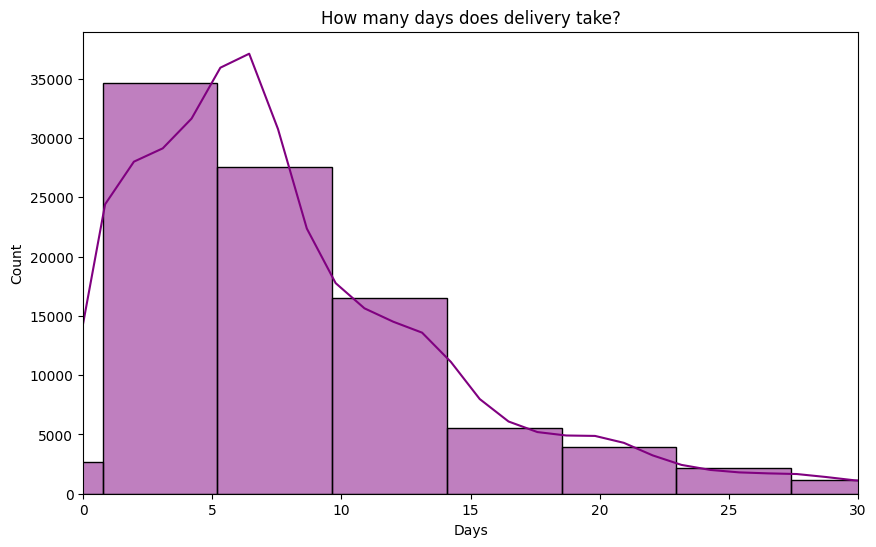

In [17]:
# Filter only delivered orders
delivered_df = order[order['order_status'] == 'delivered'].copy()

# Calculate delivery time
delivered_df['delivery_time'] = (
    delivered_df['order_delivered_customer_date'] - 
    delivered_df['order_delivered_carrier_date']
).dt.days

# Verify no missing values
print(delivered_df['delivery_time'].isnull().sum())  # should print 0

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(delivered_df['delivery_time'], bins=50, kde=True, color='purple')
plt.title('How many days does delivery take?')
plt.xlabel('Days')
plt.xlim(0, 30)  # Focus on deliveries that take up to 30 days

Sale Pulse 

C:\Users\phone\AppData\Local\Temp\ipykernel_15180\2161884536.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


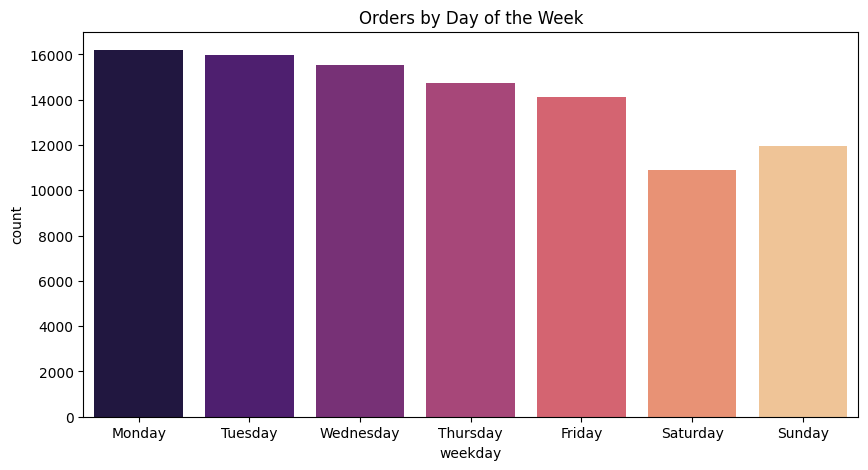

In [8]:
# Extract the day name
order['weekday'] = order['order_purchase_timestamp'].dt.day_name()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=order,
    x='weekday',
    order=days_order,
    palette='magma'
    )

plt.title('Orders by Day of the Week')
plt.show()

Order Status Breakdown

C:\Users\phone\AppData\Local\Temp\ipykernel_15180\1793480130.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=status_counts.values, y=status_counts.index, palette='rocket')


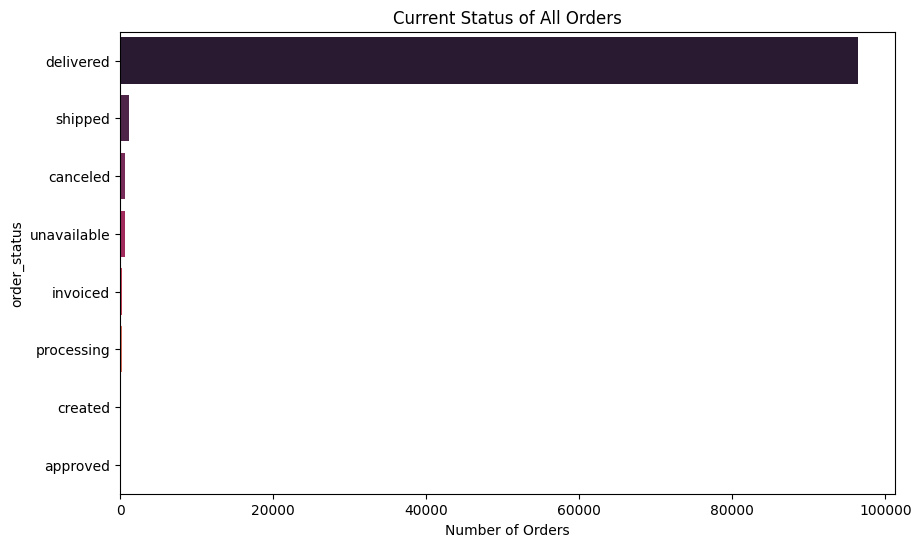

In [9]:
status_counts = order['order_status'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='rocket')
plt.title('Current Status of All Orders')
plt.xlabel('Number of Orders')
plt.show()

Orders by Hour

C:\Users\phone\AppData\Local\Temp\ipykernel_15180\1956862400.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=order, x='hour', palette='viridis')


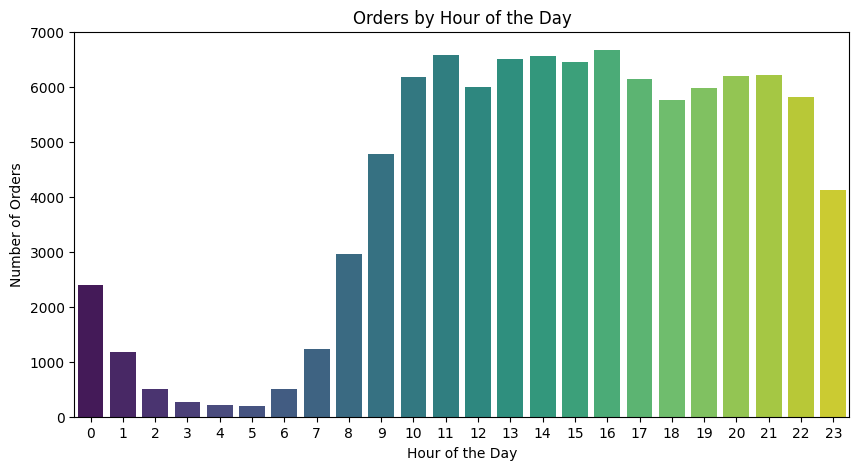

In [10]:
# Extract the hour of the day
order['hour'] = order['order_purchase_timestamp'].dt.hour

plt.figure(figsize=(10, 5))
sns.countplot(data=order, x='hour', palette='viridis')
plt.title('Orders by Hour of the Day')
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Orders')
plt.show()

Monthly Order Trend (Growth Over Time)

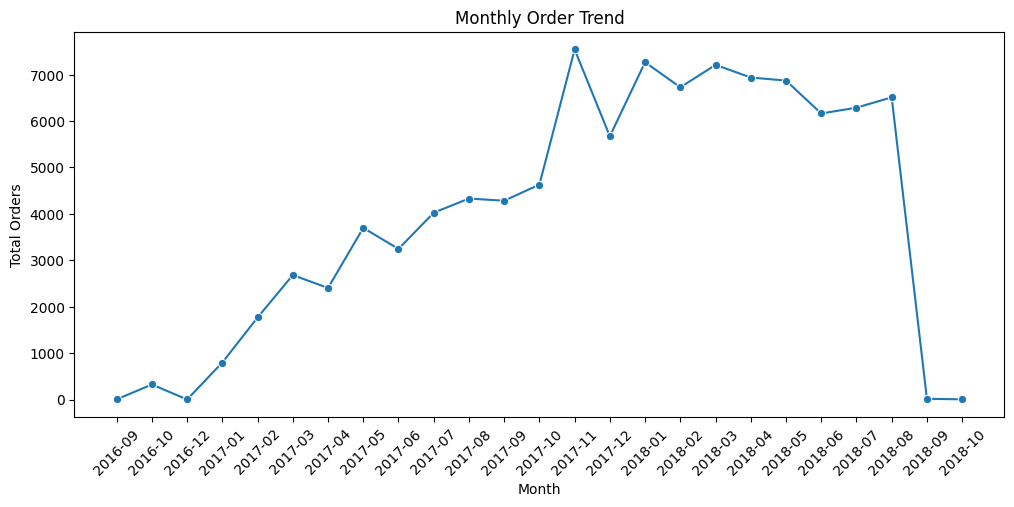

In [11]:
# Extract the month
order['month'] = order['order_purchase_timestamp'].dt.to_period('M')

# Group by month and count the number of orders
monthly_orders = order.groupby('month').size().reset_index(name='orders')

# Convert Period to string for plotting
monthly_orders['month'] = monthly_orders['month'].astype(str)

# Plot the monthly order trend
plt.figure(figsize=(12,5))

sns.lineplot(data=monthly_orders, x='month', y='orders', marker='o')

plt.title('Monthly Order Trend')
plt.xlabel('Month')
plt.ylabel('Total Orders')

plt.xticks(rotation=45)

plt.show()

Weekday vs Hour Heatmap

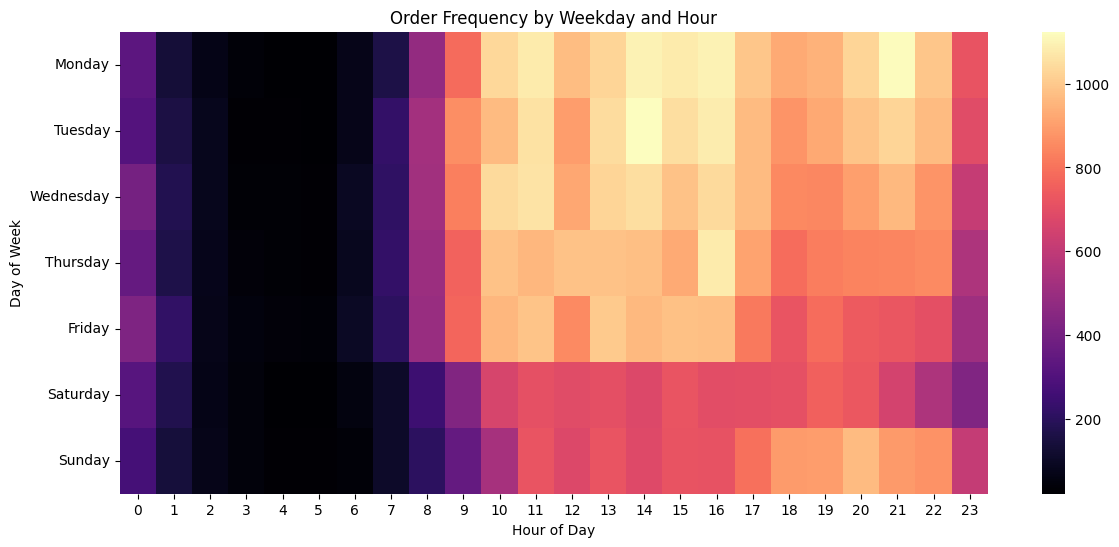

In [12]:
# Create a pivot table for the heatmap
heatmap_data = order.pivot_table(
    index=order['order_purchase_timestamp'].dt.day_name(),
    columns=order['order_purchase_timestamp'].dt.hour,
    aggfunc='size',
    fill_value=0
)

# Order the days correctly
heatmap_data = heatmap_data.reindex(days_order)

# Plot the heatmap
plt.figure(figsize=(14,6))

sns.heatmap(heatmap_data, cmap='magma')

plt.title('Order Frequency by Weekday and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')

plt.show()

Late Delivery Rate

In [13]:
# Filter delivered orders only
delivered_df = order[order['order_status'] == 'delivered'].copy()

# Calculate late deliveries
delivered_df['late_delivery'] = (
    delivered_df['order_delivered_customer_date'] >
    delivered_df['order_estimated_delivery_date']
)

# Calculate the late delivery rate
late_rate = delivered_df['late_delivery'].mean() * 100
print(f"Late Delivery Rate: {late_rate:.2f}%")

Late Delivery Rate: 8.11%


In [14]:
order.info()
delivered_df.info()

<class 'pandas.DataFrame'>
Index: 99418 entries, 0 to 99440
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99418 non-null  str           
 1   customer_id                    99418 non-null  str           
 2   order_status                   99418 non-null  str           
 3   order_purchase_timestamp       99418 non-null  datetime64[us]
 4   order_approved_at              99272 non-null  datetime64[us]
 5   order_delivered_carrier_date   97637 non-null  datetime64[us]
 6   order_delivered_customer_date  96461 non-null  datetime64[us]
 7   order_estimated_delivery_date  99418 non-null  datetime64[us]
 8   weekday                        99418 non-null  str           
 9   hour                           99418 non-null  int32         
 10  month                          99418 non-null  period[M]     
dtypes: datetime64[us](5), int32(1),